In [1]:
import json

import observe
from matplotlib import pyplot as plt

In [2]:
with open("missing.json") as f:
    observations = json.load(f)

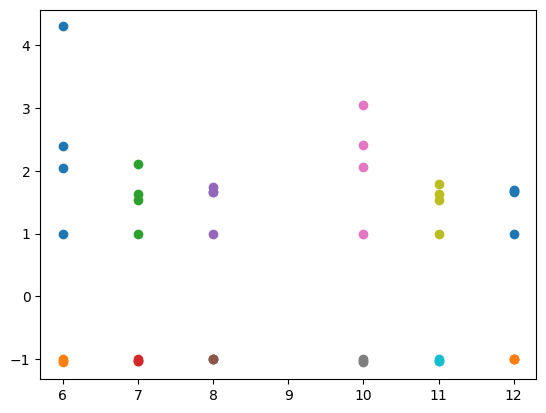

In [3]:
fig, ax = plt.subplots()

for i, result in enumerate(observations):
    if result["codec"]["id"] != "safeguards":
        continue

    if result["codec"]["codec"]["id"] == "zero":
        continue

    assert result["codec"]["lossless"]["for_codec"] is None

    (safeguarded_encode_timing,) = result["encode_timing"][
        observe.json_hash(result["codec"])
    ]
    (codec_encode_encode_timing,) = result["encode_timing"][
        observe.json_hash(result["codec"]["codec"])
    ]
    codec_encode_decode_timing, codec_decode_timing = result["decode_timing"][
        observe.json_hash(result["codec"]["codec"])
    ]
    (lossless_for_corrections_encode_timing,) = result["encode_timing"][
        observe.json_hash(result["codec"]["lossless"]["for_corrections"])
    ]

    (safeguarded_decode_timing,) = result["decode_timing"][
        observe.json_hash(result["codec"])
    ]
    (lossless_for_corrections_decode_timing,) = result["decode_timing"][
        observe.json_hash(result["codec"]["lossless"]["for_corrections"])
    ]

    ax.scatter(
        [i, i, i, i],
        [
            1.0,
            (codec_encode_encode_timing + codec_encode_decode_timing)
            / codec_encode_encode_timing,
            (
                codec_encode_encode_timing
                + codec_encode_decode_timing
                + lossless_for_corrections_encode_timing
            )
            / codec_encode_encode_timing,
            safeguarded_encode_timing / codec_encode_encode_timing,
        ],
    )
    ax.scatter(
        [i, i, i],
        [
            -1.0,
            -(codec_decode_timing + lossless_for_corrections_decode_timing)
            / codec_decode_timing,
            -safeguarded_decode_timing / codec_decode_timing,
        ],
    )

plt.show()